# Low Chin Tone Detection — **Version 6**
**이슈 해결 버전**: 같은 타입(HIGH/LOW)이 **0.2s 같은 짧은 간격**으로 끊겨 XML에 여러 개로 나뉘는 문제를 해결.

핵심 변경점
- 프레임 상태(High/Low)에 **형태학적 정리(morphological cleanup)** 적용  
  - **짧은 HIGH 섬 제거**(ex. 0.3s 미만) → LOW 연속 구간이 끊기지 않음  
  - **짧은 LOW 구멍 메우기**(ex. 0.3s 미만) → HIGH 연속 구간이 끊기지 않음
- 같은 타입 사이의 **작은 간격(<= 0.35s)** 은 **자동 병합**
- 최종적으로 **연속된 HIGH/LOW가 각각 하나의 이벤트**로 XML에 기록됨

In [1]:

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from datetime import timedelta, datetime
import xml.etree.ElementTree as ET

# Optional: your sleep_stage loader (same path as previous versions)
try:
    sys.path.append('/home/honeynaps/data/shared/integrate/sleep_stage')
    from sleep_stage.modules.iofiles import edf as edf_io
    HAVE_SLEEP_STAGE = True
except Exception:
    HAVE_SLEEP_STAGE = False
    print("[WARN] sleep_stage not available in this environment.")

In [2]:

def butter_highpass(cut_hz, fs, order=4):
    nyq=0.5*fs
    b,a=butter(order, cut_hz/nyq, btype='highpass')
    return b,a

def highpass_filter(x, fs, cut_hz=5.0, order=4):
    if not cut_hz or cut_hz<=0: return x
    b,a=butter_highpass(cut_hz, fs, order)
    return filtfilt(b,a,x)

def rms_envelope(sig, fs, win_s=0.2, hop_s=0.1):
    win=max(1,int(round(win_s*fs))); hop=max(1,int(round(hop_s*fs)))
    sq=sig.astype(float)**2
    ker=np.ones(win)/float(win)
    mov=np.convolve(sq,ker,mode='same')
    env=np.sqrt(np.maximum(mov,0.0))
    t=np.arange(len(env))/fs
    return t[::hop], env[::hop]

def rolling_median_mad(x, win):
    s=pd.Series(x)
    med=s.rolling(win,center=True,min_periods=1).median()
    mad=(s-med).abs().rolling(win,center=True,min_periods=1).median()
    mad_scaled=1.4826*mad
    med=med.fillna(method='bfill').fillna(method='ffill')
    mad_scaled=mad_scaled.fillna(method='bfill').fillna(method='ffill')
    if (mad_scaled==0).any():
        repl=float(np.median(mad_scaled[mad_scaled>0])) if (mad_scaled>0).any() else 1e-8
        mad_scaled=mad_scaled.replace(0,repl)
    return med.values, mad_scaled.values

In [3]:

from dataclasses import dataclass

@dataclass
class DetectConfig:
    fs: int = 50
    hp_cut_hz: float = 5.0
    short_win_s: float = 0.2
    long_win_s: float = 1.0
    hop_s: float = 0.1
    baseline_win_s: float = 60.0
    z_start_short: float = 4.0
    z_end_short: float = 2.5
    z_start_long: float = 3.5
    z_end_long: float = 2.0
    r_start_short: float = 2.5
    r_end_short: float = 1.6
    r_start_long: float = 2.0
    r_end_long: float = 1.4
    min_event_dur_s: float = 0.10

# --- Utilities for boolean run processing ---
def _runs_from_bool(state):
    n=len(state); runs=[]
    cur=state[0]; start=0
    for i in range(1,n):
        if state[i]!=cur:
            runs.append((cur,start,i))  # [start, i)
            cur=state[i]; start=i
    runs.append((cur,start,n))
    return runs

def boolean_morph_cleanup(state_high, hop_s, remove_islands_s=0.3, fill_holes_s=0.3):
    """
    1) Remove short True islands (< remove_islands_s)
    2) Fill short False holes surrounded by True (< fill_holes_s)
    Returns cleaned boolean array.
    """
    st = state_high.copy()
    # Pass 1: remove short True islands
    runs=_runs_from_bool(st)
    for val,s,e in runs:
        dur=(e-s)*hop_s
        if val and dur<remove_islands_s:
            st[s:e]=False
    # Pass 2: fill short False holes surrounded by True
    runs=_runs_from_bool(st)
    for i,(val,s,e) in enumerate(runs):
        if (not val):
            dur=(e-s)*hop_s
            if dur<fill_holes_s:
                left_true = (i-1)>=0 and runs[i-1][0]==True
                right_true= (i+1)<len(runs) and runs[i+1][0]==True
                if left_true and right_true:
                    st[s:e]=True
    return st

def detect_frame_state(raw_emg, cfg: DetectConfig):
    fs=cfg.fs
    x=raw_emg.astype(float)
    x=x-np.median(x)
    if cfg.hp_cut_hz and cfg.hp_cut_hz>0:
        x=highpass_filter(x, fs, cut_hz=cfg.hp_cut_hz, order=4)

    t_s, env_s=rms_envelope(x, fs, win_s=cfg.short_win_s, hop_s=cfg.hop_s)
    t_l, env_l=rms_envelope(x, fs, win_s=cfg.long_win_s,  hop_s=cfg.hop_s)

    base_win=max(3,int(round(cfg.baseline_win_s/cfg.hop_s)))
    b_s, mad_s=rolling_median_mad(env_s, base_win)
    b_l, mad_l=rolling_median_mad(env_l, base_win)
    eps=1e-8
    z_s=(env_s-b_s)/(mad_s+eps); z_l=(env_l-b_l)/(mad_l+eps)
    r_s=env_s/np.maximum(b_s,eps); r_l=env_l/np.maximum(b_l,eps)

    # --- floors (분모 하한 + 절대 진폭 가드)
    abs_floor = np.percentile(env_s, 60)              # 또는 고정값(예: 0.004)
    mad_floor_s = np.percentile(mad_s, 30)
    mad_floor_l = np.percentile(mad_l, 30)
    b_floor_s   = np.percentile(env_s, 10)
    b_floor_l   = np.percentile(env_l, 10)

    mad_eff_s = np.maximum(mad_s, mad_floor_s)
    mad_eff_l = np.maximum(mad_l, mad_floor_l)
    b_eff_s   = np.maximum(b_s, b_floor_s)
    b_eff_l   = np.maximum(b_l, b_floor_l)

    z_s = (env_s - b_s) / (mad_eff_s + 1e-8)
    z_l = (env_l - b_l) / (mad_eff_l + 1e-8)
    r_s = env_s / np.maximum(b_eff_s, 1e-8)
    r_l = env_l / np.maximum(b_eff_l, 1e-8)

    amp_guard = (env_s > abs_floor) | (env_l > abs_floor)

    # --- 시작/종료 조건(AND 게이팅)
    start = amp_guard & (
        ((z_s > cfg.z_start_short) & (r_s > cfg.r_start_short)) |
        ((z_l > cfg.z_start_long)  & (r_l > cfg.r_start_long))
    )
    end = (
        (z_s < cfg.z_end_short) & (r_s < cfg.r_end_short) &
        (z_l < cfg.z_end_long)  & (r_l < cfg.r_end_long)
    )


    # start = (z_s>cfg.z_start_short)|(z_l>cfg.z_start_long)|(r_s>cfg.r_start_short)|(r_l>cfg.r_start_long)
    # end   = (z_s<cfg.z_end_short) & (z_l<cfg.z_end_long) & (r_s<cfg.r_end_short) & (r_l<cfg.r_end_long)

    state=np.zeros_like(env_s,dtype=bool)
    in_evt=False
    for i in range(len(env_s)):
        if not in_evt and start[i]:
            in_evt=True
        elif in_evt and end[i]:
            in_evt=False
        state[i]=in_evt

    # --- Morphological cleanup to eliminate tiny flips ---
    state_clean = boolean_morph_cleanup(state, cfg.hop_s,
                                        remove_islands_s=0.3,  # 0.3s: kills 0.1~0.2s HIGH spikes
                                        fill_holes_s=0.3)       # 0.3s: fills 0.1~0.2s LOW holes
    debug={
        "t_short":t_s,"env_short":env_s,"base_short":b_s,
        "t_long":t_l,"env_long":env_l,"base_long":b_l,
        "state_high_raw":state,
        "state_high":state_clean
    }
    return debug

In [4]:

def load_edf_raw_v6(edf_path, fs=50):
    if not HAVE_SLEEP_STAGE:
        raise RuntimeError("sleep_stage not available. Run this where it's installed.")
    edf,_=edf_io.load(path=edf_path, preload=True, resample=fs, preset="STAGENET",
                      exclude=True, missing_ch='raise')
    meas_date=edf.info['meas_date'].replace(tzinfo=None)
    data=edf.get_data(); ch_names=edf.ch_names
    SID_MAP={'F3-':'F3_2','F4-':'F4_1','C3-':'C3_2','C4-':'C4_1','O1-':'O1_2','O2-':'O2_1','LOC':'LOC','ROC':'ROC','EMG':'CHIN'}
    sigs={}
    for i,nm in enumerate(ch_names):
        if nm in SID_MAP: sigs[SID_MAP[nm]]=data[i]
        else: sigs[SID_MAP.get(nm[:3],nm[:3])]=data[i]
    if 'CHIN' not in sigs: raise RuntimeError("CHIN channel not found")
    chin=sigs['CHIN'].astype(float)*1000.0
    return chin, meas_date, ch_names

In [5]:

def merged_runs_from_state(t_frames, env_short, state_high, total_len_s,
                           min_dur_s=0.5, merge_same_gap_s=0.35):
    """
    Create merged HIGH/LOW runs across whole [0,total_len_s).
    - merge_same_gap_s: if two same-type runs are separated by a short opposite-type gap
                        ≤ this value, we merge them into a single run.
    """
    hop = t_frames[1]-t_frames[0] if len(t_frames)>1 else 0.1
    runs=_runs_from_bool(state_high)
    seq=[]
    for val,s,e in runs:
        start=s*hop; end=e*hop
        if end>total_len_s: end=total_len_s
        dur=end-start
        if dur<min_dur_s: 
            # discard too-short runs by flipping to the neighbor type
            # here we simply skip emitting; the gap will be absorbed by neighbors during merge
            continue
        avg = float(np.mean(env_short[s:e])) if e> s else 0.0
        seq.append({"start":start,"end":end,"duration":dur,
                    "type":"HIGH" if val else "LOW","avg_rms":avg})
    # Merge same-type runs separated by short gaps
    if not seq: return []
    merged=[seq[0]]
    for r in seq[1:]:
        prev=merged[-1]
        if r["type"]==prev["type"] and (r["start"]-prev["end"])<=merge_same_gap_s:
            # combine; recompute weighted avg_rms by duration
            w1=prev["duration"]; w2=r["duration"]
            avg=(prev["avg_rms"]*w1 + r["avg_rms"]*w2)/max(w1+w2,1e-8)
            prev["end"]=r["end"]; prev["duration"]=prev["end"]-prev["start"]; prev["avg_rms"]=avg
        else:
            merged.append(r)
    return merged

def save_merged_HL_xml(meas_date, merged_runs, xml_path, total_len_s):
    root=ET.Element("annotationlist")
    ET.SubElement(root,"recording_duration").text=f"{total_len_s:.6f}"
    for ev in merged_runs:
        ann=ET.SubElement(root,"annotation")
        ET.SubElement(ann,"onset").text=(meas_date+timedelta(seconds=ev["start"])).strftime("%Y-%m-%dT%H:%M:%S.%f")
        ET.SubElement(ann,"duration").text=f"{ev['duration']:.6f}"
        ET.SubElement(ann,"description").text=f"{ev['type']}_CHIN_TONE_{ev['avg_rms']:.4f}"
        ET.SubElement(ann,"location").text="EEG-EMG"
    tree=ET.ElementTree(root); ET.indent(tree, space="  ", level=0)
    with open(xml_path,"wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    return len(merged_runs)

In [6]:
# ====== CONFIG ======
fs=50
cfg=DetectConfig(fs=fs)
EDF_DIR='/home/honeynaps/data/GOLDEN/EDF2'
OUTPUT_DIR='./output_v6_fillgaps'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MAX_FILES=5  # None to process all

edf_files=[f for f in os.listdir(EDF_DIR) if f.lower().endswith('.edf')]
edf_files.sort()
if MAX_FILES is not None: edf_files=edf_files[:MAX_FILES]
print(f"Found {len(edf_files)} EDF files")

# ====== CALCULATE N3 ABSOLUTE THRESHOLD ======
absolute_threshold, n3_average = calculate_n3_threshold_and_analyze(edf_files, fs=fs)

# ====== MAIN PROCESSING WITH ABSOLUTE THRESHOLD ======
print(f"\n=== Processing with Absolute Threshold ({absolute_threshold:.6f}) ===")
summary=[]
for i,fname in enumerate(edf_files,1):
    print(f"\n[{i}/{len(edf_files)}] {fname}")
    chin, meas_date, ch_names = load_edf_raw_v6(os.path.join(EDF_DIR,fname), fs=fs)
    total_len_s=len(chin)/fs

    dbg = detect_frame_state(chin, cfg)
    t_frames=dbg["t_short"]; env_short=dbg["env_short"]; state_high_orig=dbg["state_high"]
    
    # Apply absolute threshold
    state_high = apply_absolute_threshold(env_short, state_high_orig, absolute_threshold)

    runs = merged_runs_from_state(t_frames, env_short, state_high, total_len_s,
                                  min_dur_s=0.5, merge_same_gap_s=0.35)  # <-- 0.35s gap merge

    base=os.path.splitext(fname)[0]
    xml_path=os.path.join(OUTPUT_DIR, f"{base}_CHIN_MERGED_HL_V6_AbsThresh.xml")
    n = save_merged_HL_xml(meas_date, runs, xml_path, total_len_s)
    print(f"  XML merged runs saved: {n} -> {xml_path}")

    nH=sum(1 for r in runs if r["type"]=="HIGH")
    nL=sum(1 for r in runs if r["type"]=="LOW")
    dH=sum(r["duration"] for r in runs if r["type"]=="HIGH")
    dL=sum(r["duration"] for r in runs if r["type"]=="LOW")
    summary.append((fname, nH, nL, dH, dL, xml_path))

print("\n=== SUMMARY WITH ABSOLUTE THRESHOLD ===")
for row in summary:
    fname, nH, nL, dH, dL, path = row
    print(f"{fname}: HIGH n={nH}, dur={dH:.1f}s | LOW n={nL}, dur={dL:.1f}s -> {path}")

# ====== SLEEP STAGE ANALYSIS ======
stage_stats = analyze_by_sleep_stage(edf_files, fs=fs, absolute_threshold=absolute_threshold)

print(f"\n=== ABSOLUTE THRESHOLD SUMMARY ===")
print(f"N3 average energy: {n3_average:.6f}")
print(f"Absolute threshold (1.2x N3): {absolute_threshold:.6f}")
print("Any segment with energy >= absolute threshold is forced to HIGH (not low chin tone)")
print("Done.")

Found 5 EDF files


NameError: name 'calculate_n3_threshold_and_analyze' is not defined

In [ ]:
# Load sleep stages from XML for analysis
def load_sleep_stage_xml(xml_path):
    """Load sleep stage XML and return labels"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        sleep_stages = []
        
        for annotation in root.findall("annotation"):
            description = annotation.find("description").text
            if 'W' in description:
                sleep_stages.append(0)  # Wake
            elif "R" in description:
                sleep_stages.append(1)  # REM
            elif "1" in description:
                sleep_stages.append(2)  # N1
            elif "2" in description:
                sleep_stages.append(3)  # N2
            elif "3" in description:
                sleep_stages.append(4)  # N3
        
        return sleep_stages
    except Exception as e:
        print(f"Error reading SLEEP XML {xml_path}: {e}")
        return []

# Calculate N3 average and apply absolute threshold
def calculate_n3_threshold_and_analyze(edf_files, fs=50):
    """Calculate N3 average energy and analyze by sleep stage"""
    all_n3_energies = []
    stage_analysis_data = []
    
    # Stage names for display
    stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']
    
    # First pass: collect N3 data to calculate threshold
    print("\n=== Calculating N3 Threshold ===")
    for fname in edf_files:
        try:
            print(f"Processing {fname} for N3 threshold...")
            
            # Load SLEEP XML for sleep stages
            base_name = os.path.splitext(fname)[0]
            sleep_xml_path = os.path.join('/home/honeynaps/data/GOLDEN/EBX2/SLEEP', f"{base_name}_SLEEP.xml")
            
            if not os.path.exists(sleep_xml_path):
                print(f"  SLEEP XML not found: {sleep_xml_path}")
                continue
            
            sleep_stages = load_sleep_stage_xml(sleep_xml_path)
            if not sleep_stages:
                continue
                
            # Load EDF and calculate RMS envelope
            chin, meas_date, ch_names = load_edf_raw_v6(os.path.join(EDF_DIR, fname), fs=fs)
            
            # Calculate RMS envelope (same as in main processing)
            x = chin.astype(float) - np.median(chin)
            if cfg.hp_cut_hz > 0:
                x = highpass_filter(x, fs, cut_hz=cfg.hp_cut_hz, order=4)
            t_frames, env_short = rms_envelope(x, fs, win_s=cfg.short_win_s, hop_s=cfg.hop_s)
            
            # Map envelope frames to 30-second epochs (assuming 30s sleep stage epochs)
            epoch_length_s = 30.0
            epoch_frames = int(epoch_length_s / cfg.hop_s)  # frames per epoch
            
            # Collect N3 energies
            for epoch_idx, stage in enumerate(sleep_stages):
                if stage == 4:  # N3 stage
                    start_frame = epoch_idx * epoch_frames
                    end_frame = min((epoch_idx + 1) * epoch_frames, len(env_short))
                    
                    if start_frame < len(env_short):
                        epoch_energies = env_short[start_frame:end_frame]
                        all_n3_energies.extend(epoch_energies)
                        
        except Exception as e:
            print(f"  Error processing {fname}: {e}")
            continue
    
    # Calculate N3 average and threshold
    if all_n3_energies:
        n3_average = np.mean(all_n3_energies)
        absolute_threshold = n3_average * 1.2  # 1.2x N3 average
        print(f"N3 average energy: {n3_average:.6f}")
        print(f"Absolute threshold (1.2x N3): {absolute_threshold:.6f}")
    else:
        print("No N3 data found!")
        absolute_threshold = 0.01  # fallback value
        n3_average = absolute_threshold / 1.2
    
    return absolute_threshold, n3_average

# Apply absolute threshold to modify state
def apply_absolute_threshold(env_short, state_high, absolute_threshold):
    """Apply absolute threshold: if energy >= 1.2x N3 average, force to HIGH (not low chin tone)"""
    state_modified = state_high.copy()
    
    # Find frames where energy is above absolute threshold
    high_energy_mask = env_short >= absolute_threshold
    
    # Force these frames to HIGH (True) - they cannot be low chin tone
    state_modified[high_energy_mask] = True
    
    # Count modifications
    modifications = np.sum((state_high == False) & (state_modified == True))
    print(f"  Applied absolute threshold: {modifications} frames changed from LOW to HIGH")
    
    return state_modified

# Analysis by sleep stage
def analyze_by_sleep_stage(edf_files, fs=50, absolute_threshold=None):
    """Analyze low chin tone ratios by sleep stage"""
    stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']
    stage_stats = {stage: {'low_frames': 0, 'total_frames': 0, 'low_duration': 0, 'total_duration': 0} 
                  for stage in stage_names}
    
    print("\n=== Sleep Stage Analysis ===")
    
    for fname in edf_files:
        try:
            print(f"Analyzing {fname} by sleep stage...")
            
            # Load SLEEP XML for sleep stages  
            base_name = os.path.splitext(fname)[0]
            sleep_xml_path = os.path.join('/home/honeynaps/data/GOLDEN/EBX2/SLEEP', f"{base_name}_SLEEP.xml")
            
            if not os.path.exists(sleep_xml_path):
                continue
                
            sleep_stages = load_sleep_stage_xml(sleep_xml_path)
            if not sleep_stages:
                continue
                
            # Load EDF and process
            chin, meas_date, ch_names = load_edf_raw_v6(os.path.join(EDF_DIR, fname), fs=fs)
            
            # Detect frame state
            dbg = detect_frame_state(chin, cfg)
            t_frames, env_short, state_high = dbg["t_short"], dbg["env_short"], dbg["state_high"]
            
            # Apply absolute threshold if provided
            if absolute_threshold is not None:
                state_high = apply_absolute_threshold(env_short, state_high, absolute_threshold)
            
            # Map to sleep stages (30-second epochs)
            epoch_length_s = 30.0
            epoch_frames = int(epoch_length_s / cfg.hop_s)
            
            for epoch_idx, stage in enumerate(sleep_stages):
                if 0 <= stage <= 4:  # Valid sleep stage
                    stage_name = stage_names[stage]
                    
                    start_frame = epoch_idx * epoch_frames
                    end_frame = min((epoch_idx + 1) * epoch_frames, len(state_high))
                    
                    if start_frame < len(state_high):
                        epoch_state = state_high[start_frame:end_frame]
                        
                        # Count low chin tone frames (state_high == False means LOW)
                        low_frames = np.sum(~epoch_state)  # Count False values
                        total_frames = len(epoch_state)
                        
                        stage_stats[stage_name]['low_frames'] += low_frames
                        stage_stats[stage_name]['total_frames'] += total_frames
                        stage_stats[stage_name]['low_duration'] += low_frames * cfg.hop_s
                        stage_stats[stage_name]['total_duration'] += total_frames * cfg.hop_s
                        
        except Exception as e:
            print(f"  Error analyzing {fname}: {e}")
            continue
    
    # Print results
    print(f"\n{'Stage':<8} {'Low Frames':<12} {'Total Frames':<14} {'Low %':<10} {'Low Duration':<14} {'Total Duration':<16}")
    print("-" * 80)
    
    for stage_name in stage_names:
        stats = stage_stats[stage_name]
        if stats['total_frames'] > 0:
            low_pct = (stats['low_frames'] / stats['total_frames']) * 100
            print(f"{stage_name:<8} {stats['low_frames']:<12} {stats['total_frames']:<14} {low_pct:<10.1f} "
                  f"{stats['low_duration']:<14.1f} {stats['total_duration']:<16.1f}")
        else:
            print(f"{stage_name:<8} {'0':<12} {'0':<14} {'0.0':<10} {'0.0':<14} {'0.0':<16}")
    
    return stage_stats

In [ ]:
# ====== DETAILED SLEEP STAGE ANALYSIS AND COMPARISON ======
print("\n" + "="*80)
print("DETAILED ANALYSIS WITH ABSOLUTE THRESHOLD")
print("="*80)

print(f"\nAbsolute Threshold Settings:")
print(f"  N3 Average Energy: {n3_average:.6f}")
print(f"  Absolute Threshold (1.2x N3): {absolute_threshold:.6f}")
print(f"  Rule: Any segment ≥ {absolute_threshold:.6f} is forced to HIGH (not low chin tone)")

print(f"\nSleep Stage Low Chin Tone Analysis:")
print(f"  - Shows proportion of time spent in LOW chin tone for each sleep stage")
print(f"  - LOW chin tone = reduced muscle activity (atonia)")
print(f"  - HIGH chin tone = normal/elevated muscle activity")

# Calculate overall statistics
if 'stage_stats' in locals():
    total_low_duration = sum(stats['low_duration'] for stats in stage_stats.values())
    total_duration = sum(stats['total_duration'] for stats in stage_stats.values())
    overall_low_pct = (total_low_duration / total_duration * 100) if total_duration > 0 else 0
    
    print(f"\nOverall Statistics:")
    print(f"  Total recording time: {total_duration/3600:.1f} hours")
    print(f"  Total low chin tone time: {total_low_duration/3600:.1f} hours ({overall_low_pct:.1f}%)")
    print(f"  Total high chin tone time: {(total_duration-total_low_duration)/3600:.1f} hours ({100-overall_low_pct:.1f}%)")
    
    print(f"\nClinical Interpretation:")
    print(f"  REM: Should have high % of low chin tone (muscle atonia expected)")
    print(f"  N3:  May have moderate % of low chin tone (deep sleep relaxation)")
    print(f"  N1/N2: Variable % depending on sleep depth")
    print(f"  Wake: Should have low % of low chin tone (muscle activity expected)")

# Process one file in detail to show before/after absolute threshold effect
if edf_files:
    print(f"\n" + "="*80)
    print("ABSOLUTE THRESHOLD EFFECT ANALYSIS (First File)")
    print("="*80)
    
    fname = edf_files[0]
    print(f"Analyzing threshold effect on: {fname}")
    
    try:
        # Load and process
        chin, meas_date, ch_names = load_edf_raw_v6(os.path.join(EDF_DIR, fname), fs=fs)
        dbg = detect_frame_state(chin, cfg)
        t_frames, env_short, state_orig = dbg["t_short"], dbg["env_short"], dbg["state_high"]
        
        # Apply threshold
        state_thresh = apply_absolute_threshold(env_short, state_orig, absolute_threshold)
        
        # Count changes
        total_frames = len(state_orig)
        changed_frames = np.sum((state_orig == False) & (state_thresh == True))
        frames_above_thresh = np.sum(env_short >= absolute_threshold)
        
        print(f"  Total frames: {total_frames}")
        print(f"  Frames with energy ≥ threshold: {frames_above_thresh} ({frames_above_thresh/total_frames*100:.1f}%)")
        print(f"  Frames changed from LOW to HIGH: {changed_frames} ({changed_frames/total_frames*100:.1f}%)")
        
        # Energy distribution analysis
        low_orig = env_short[~state_orig]  # LOW frames before threshold
        low_thresh = env_short[~state_thresh]  # LOW frames after threshold
        high_orig = env_short[state_orig]  # HIGH frames before threshold  
        high_thresh = env_short[state_thresh]  # HIGH frames after threshold
        
        print(f"\n  Energy Distribution Analysis:")
        if len(low_orig) > 0:
            print(f"    LOW frames (before): count={len(low_orig)}, mean={np.mean(low_orig):.6f}, max={np.max(low_orig):.6f}")
        if len(low_thresh) > 0:
            print(f"    LOW frames (after):  count={len(low_thresh)}, mean={np.mean(low_thresh):.6f}, max={np.max(low_thresh):.6f}")
        if len(high_orig) > 0:
            print(f"    HIGH frames (before): count={len(high_orig)}, mean={np.mean(high_orig):.6f}, min={np.min(high_orig):.6f}")
        if len(high_thresh) > 0:
            print(f"    HIGH frames (after):  count={len(high_thresh)}, mean={np.mean(high_thresh):.6f}, min={np.min(high_thresh):.6f}")
            
        print(f"\n  Effect: Absolute threshold prevents very high energy segments from being classified as low chin tone")
        print(f"  This improves specificity by avoiding false positive low chin tone detection during movement artifacts")
        
    except Exception as e:
        print(f"  Error in detailed analysis: {e}")

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

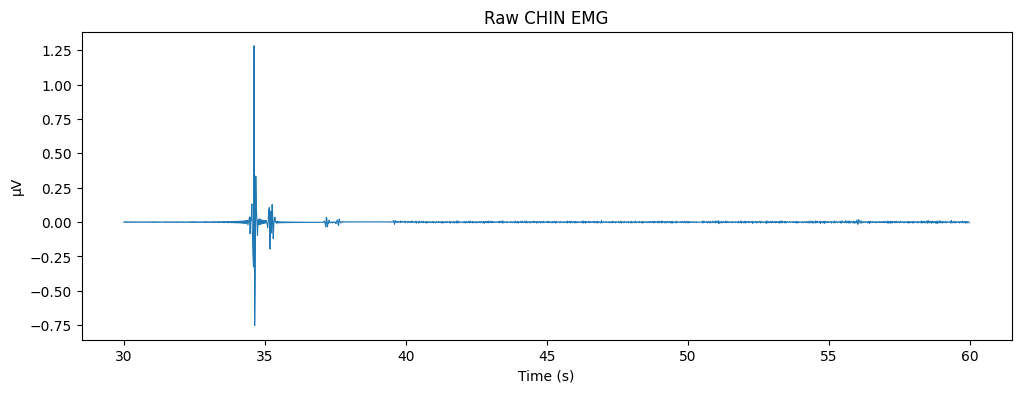

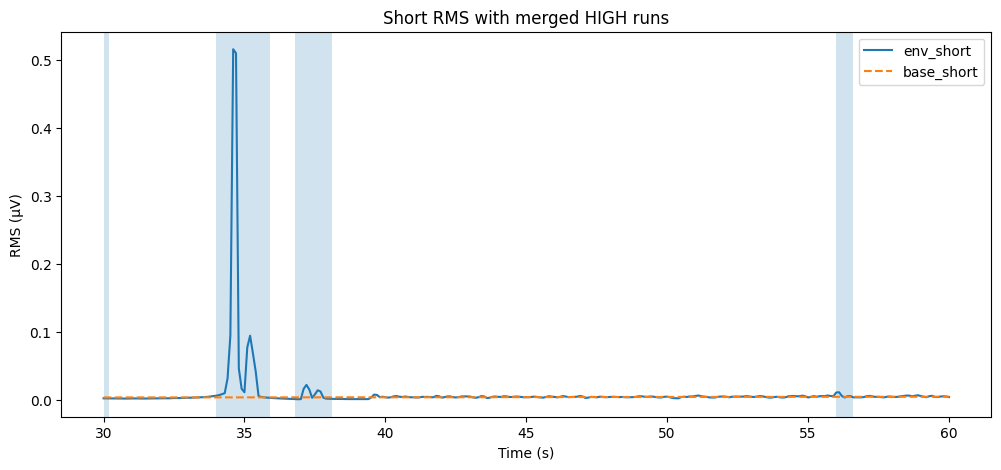

In [ ]:

# Optional: quick QA visualization on the last file
try:
    start_s, dur_s = 30.0, 30.0
    t=np.arange(len(chin))/fs
    m0=int(round(start_s*fs)); m1=int(round((start_s+dur_s)*fs))

    plt.figure(figsize=(12,4))
    plt.plot(t[m0:m1], chin[m0:m1], linewidth=0.8)
    plt.title("Raw CHIN EMG"); plt.xlabel("Time (s)"); plt.ylabel("µV")
    plt.show()

    mask=(t_frames>=start_s)&(t_frames<=start_s+dur_s)
    plt.figure(figsize=(12,5))
    plt.plot(t_frames[mask], env_short[mask], label="env_short")
    plt.plot(t_frames[mask], dbg["base_short"][mask], label="base_short", linestyle="--")
    # Shade merged HIGH runs
    for r in runs:
        if r["type"]!="HIGH": continue
        if r["end"]<start_s or r["start"]>start_s+dur_s: continue
        plt.axvspan(max(r["start"],start_s), min(r["end"],start_s+dur_s), alpha=0.2)
    plt.legend(); plt.title("Short RMS with merged HIGH runs")
    plt.xlabel("Time (s)"); plt.ylabel("RMS (µV)"); plt.show()
except Exception as e:
    print("Visualization skipped:", e)